# Bootstrap Sampling: SPY (S&P 500 Index)
This study is broken down into two parts. The first section explores bootstrap resampling relating to monthly S&P 500 index returns. The objective is to generate a 95% confidence interval. The second section investigates whether the bootstrap can be converted into position sizing rules that outperforms the index on a risk-adjusted basis.

In [289]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
import warnings

# Settings
plt.style.use("ggplot")
warnings.filterwarnings("ignore")

In [290]:
# Download monthly close data
data = yf.download("SPY", period="max", interval="1mo", auto_adjust=True)["Close"]

# 95% Confidence Interval
intervals = [2.5, 97.5]

data.describe()

[*********************100%***********************]  1 of 1 completed


Ticker,SPY
count,400.000000
mean,169.861448
std,157.660242
min,24.175385
25%,70.306787
50%,96.127071
75%,231.728386
max,690.085327


In [291]:
# Comptute returns
returns = (data / data.shift(1)) - 1
returns = returns["SPY"].dropna()

print(f"Sample mean: {returns.mean():.4f}")
print(f"Sample sdev: {returns.std():.4f}")
print(f"Sample skew: {returns.skew():.4f}")
print(f"Sample kurt: {returns.kurtosis():.4f}")

Sample mean: 0.0093
Sample sdev: 0.0430
Sample skew: -0.5374
Sample kurt: 0.9540


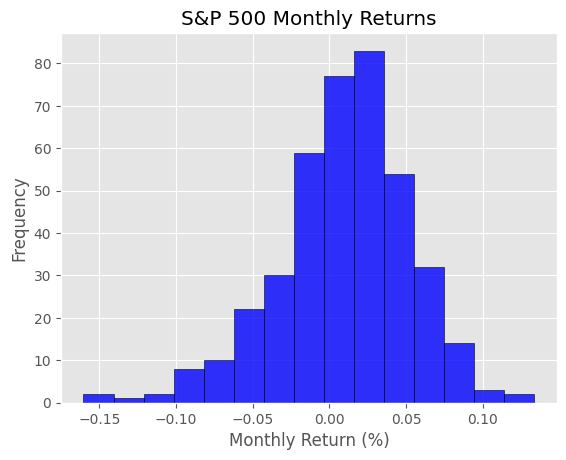

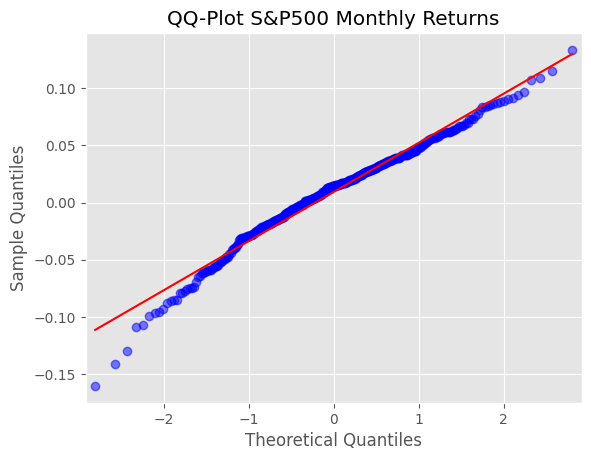

In [292]:
# Plot the histogram of monthly returns
plt.hist(returns, bins=15, color="blue", alpha=0.8, edgecolor="black")
plt.xlabel("Monthly Return (%)")
plt.ylabel("Frequency")
plt.title("S&P 500 Monthly Returns")
plt.show()

# Plot the Q-Q of monthly returns
sm.qqplot(returns, line="s", markerfacecolor='b', markeredgecolor='b', alpha=0.5)
plt.title("QQ-Plot S&P500 Monthly Returns")
plt.show()

### Part 1: Bootstrap Resampling: Mean and Standard Deviation
Knowing the average return of a market index and the variability of its returns is an essential piece of information for investors. These statistics form the foundation of expectations and financial models.

$$
R_t = \frac{P_t-P_{t-1}}{P_{t-1}}
$$

Unlike conventional resampling, time-series data requires the maintenance of its temporal structure. To keep this structure, individual sets of returns are generated into "blocks". A block size is length $N$. A block starting at time $i$ is defined as $B_i=\{R_i,R_{i+1},...,R_{i+N-1}\}$. Thus, the set of all overlapping blocks is,

$$
\Beta = \{B_1,B_2,...,B_{T-N+1}\}
$$

These blocks are then sampled with replacement to compute the statistic $T$, we want to estimate. Because we are interested in the average (expected) return and its variability, out statistics are $\hat{E[X]}$ and $\hat{Var[X]}$, where $X$ is a continuous random variable of monthly returns, $E[X]$ is its expected value, and $Var[X]$ its variance.

In [293]:
# Create blocks (keeping temporal structure)
N = int(len(returns) / 12)
blocks = np.array_split(returns, N)

In [294]:
B = 10_000

rng = np.random.default_rng()

bootstrap_mu = []
bootstrap_sd = []
for b in range(B):
    idx = rng.integers(0, len(blocks), size=N)
    sampled_blocks = [blocks[i] for i in idx]
    sample = np.concatenate(sampled_blocks)
    
    # Save the resampled statistics
    bootstrap_mu.append(sample.mean())
    bootstrap_sd.append(sample.std())

mu_ci = np.percentile(bootstrap_mu, intervals)
sd_ci = np.percentile(bootstrap_sd, intervals)

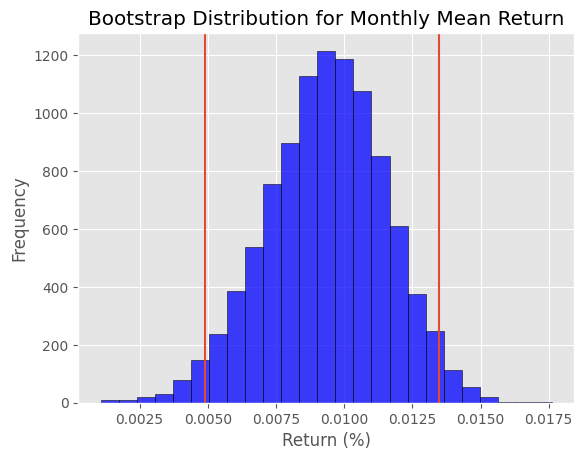

Bootstrap mean:           0.009352326712796342
Bootstrap standard error: 0.0021920772609732918
2.5% Confidence Interval: 0.004884713259708044
97.5% Confidence Interval: 0.013464199475069893


In [295]:
# Plot the bootstrap distribution for mean
plt.hist(bootstrap_mu, bins=25, color="blue", alpha=0.75, edgecolor="black")
plt.axvline(mu_ci[0])
plt.axvline(mu_ci[1])
plt.title("Bootstrap Distribution for Monthly Mean Return")
plt.xlabel("Return (%)")
plt.ylabel("Frequency")
plt.show()

# Print bootstrap statistics (simple returns)
print(f"Bootstrap mean:           {np.mean(bootstrap_mu)}")
print(f"Bootstrap standard error: {np.std(bootstrap_mu)}")
print(f"{intervals[0]}% Confidence Interval: {mu_ci[0]}")
print(f"{intervals[1]}% Confidence Interval: {mu_ci[1]}")

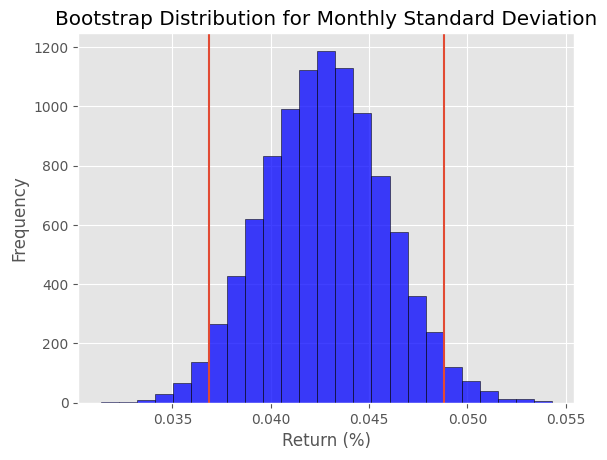

Bootstrap mean:           0.04275517116860012
Bootstrap standard error: 0.003074023630227397
2.5% Confidence Interval: 0.03686927462699202
97.5% Confidence Interval: 0.04882585832067417


In [296]:
# Plot the bootstrap distribution for standard deviation
plt.hist(bootstrap_sd, bins=25, color="blue", alpha=0.75, edgecolor="black")
plt.axvline(sd_ci[0])
plt.axvline(sd_ci[1])
plt.title("Bootstrap Distribution for Monthly Standard Deviation")
plt.xlabel("Return (%)")
plt.ylabel("Frequency")
plt.show()

# Print bootstrap statistics (simple returns)
print(f"Bootstrap mean:           {np.mean(bootstrap_sd)}")
print(f"Bootstrap standard error: {np.std(bootstrap_sd)}")
print(f"{intervals[0]}% Confidence Interval: {sd_ci[0]}")
print(f"{intervals[1]}% Confidence Interval: {sd_ci[1]}")

### Part 2: Position Sizing
The previous section covered bootstrap sampling to estimate the sampling distribution for the mean and variance of monthly S&P 500 returns. The problem we know want to investigate is whether we can generate position sizing rules using boostrap resampling.

A well-known mean-varaince sizing rule is,

$$
w^*=\frac{\mu}{\sigma^2}
$$

This rule is intuitive because if we expect a higher return, we would want to increase our weight. If we experience a higher volatility, we want to scale down and reduce risk. This approach uses a single estimate for $\mu$ and $\sigma$ which can introduce noise and bias. Instead, we can use bootstrap resampling to compute a distribution of weights.

$$
w_b=\frac{\mu_b}{\sigma^2_b}
$$

By estimating the sampling distribution of mean-variance weights, we can ask more interesting questions. Importantly, we want to understand this information historically, so we will use a walk-forward style procedure. The block length is fixed to 12 months, and uses overlapping windows.

In [297]:
# Updated Bootstrap Loop with Shrinkage and Constraints
B = 10_000 
L = 60 
block_len = 12
rng = np.random.default_rng()

# 1. Calculate global variance for shrinkage target
global_var = returns.var()
delta = 0.2  # Shrinkage factor (20% weight to global average)

bootstrap_stats = {"w": [], "mu": [], "sd": []}

for t in range(L, len(returns)):
    s_returns = np.asarray(returns[t-60:t])
    N = len(s_returns) - block_len + 1
    blocks = np.lib.stride_tricks.sliding_window_view(s_returns, block_len)
    k = int(np.ceil(len(s_returns) / block_len))

    idx = rng.integers(0, N, size=(B, k))
    sample = blocks[idx].reshape(B, -1)[:, :len(s_returns)]

    mu_t = sample.mean(axis=1)
    # 2. Apply Shrinkage to the Variance
    # This prevents the weight from exploding when sample variance is low
    var_t = (1 - delta) * sample.var(axis=1) + delta * global_var
    
    # 3. Apply Weight Constraints (Long-only, capped at 1.5x leverage)
    raw_w = mu_t / var_t
    constrained_w = np.clip(raw_w, 0, 1.5) 

    bootstrap_stats["w"].append(constrained_w)
    bootstrap_stats["mu"].append(mu_t)
    bootstrap_stats["sd"].append(np.sqrt(var_t))

In [298]:
assert len(bootstrap_stats["w"]) == len(bootstrap_stats["mu"]) == len(bootstrap_stats["sd"])

Before generating position sizing rules, lets visually see how the bootstrap samples change over time.